# Quantum Repeater Network — Metrics Study

All figures studying distillation, multiplexing, radius, P_BSM, and multiphoton error.  
All runs use `multiphoton=False` except **Figure 7** (multiphoton comparison).

| # | Figure | X-axis |
|---|--------|--------|
| 1 | Master: all mux × before/after | Distillation level |
| 2 | Distillation level study | Distillation level (lines = radii) |
| 3 | Before vs After swap | Network radius |
| 4 | Distillation vs Accumulated mux | Network radius |
| 5 | Distillation vs Single-burst mux | Network radius |
| 6 | P_BSM sweep — all configurations | P_BSM |
| 7 | Multiphoton error ON vs OFF | Network radius |
| 8 | Dijkstra diagnostics: hops & distance vs P_BSM | P_BSM (panels = radii) |
| 9 | Bonus density plots: SKR heatmap, KDE hop/distance, joint density | — |

> Raise `N_NODES` and `N_TRIALS` for smoother curves at the cost of runtime.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sequential_repeaters_dist import (
    RepeaterParams, QuantumRepeaterNetwork,
    build_radius_graph, build_density_graph, density_to_scale
)

## Global settings

In [2]:
# ── Physical parameters ──────────────────────────────────────────────────────
def make_params(P_BSM=0.5):
    p            = RepeaterParams()
    p.p_det      = 0.95
    p.alpha      = 0.18
    p.q_0        = 0.01
    p.nu         = 1e9
    p.R_dark     = 100
    p.delta_det  = 100e-12
    p.p_pair     = 0.05
    p.eta_c      = 0.8
    p.P_BSM      = P_BSM
    p.T_coh      = 0.05
    return p

# ── Sweep knobs ──────────────────────────────────────────────────────────────
N_NODES  = 100
N_TRIALS = 3
BETA     = 2.6261
MU       = 0.0233
M_MUX    = 1e4

# Radius sweep — from intra-city to inter-city [km]
# Chosen so that long radii give appreciable loss and reachability < 100 %
RADII       = np.array([10, 50, 100, 175, 250, 325, 400])  # km
DIST_LEVELS = [1, 2, 3]
MUX_MODES   = [None, 'single_burst', 'accumulated']
DIST_TIMES  = ['before_swap', 'after_swap']

# Fixed large radius for P_BSM sweep
RADIUS_LARGE    = 120    # km
P_BSM_VALUES    = np.linspace(0.05, 0.95, 12)

# Radii for Dijkstra and KDE panels
RADII_DIJKSTRA  = [10, 40, 160]   # km
RADII_KDE       = [10, 40, 160]   # km
SOURCE_NODE     = 0
TARGET_NODE     = N_NODES - 1

# ── Aesthetics ───────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', font_scale=1.05)

METRIC_KEYS   = ['avg_rate', 'avg_dist_weighted_rate', 'reachability']
METRIC_LABELS = {
    'avg_rate':               'Avg rate  [pairs/s]',
    'avg_dist_weighted_rate': 'Avg dist-weighted rate  [pairs·km/s]',
    'reachability':           'Reachability  [%]',
}

print('Settings loaded.')

Settings loaded.


## Core helpers

In [3]:
def run_metrics(
    radius_km,
    distillation=False,
    multiplexing_type=None,
    distillation_level=1,
    distillation_time='before_swap',
    multiphoton=False,
    P_BSM=0.5,
    n_trials=N_TRIALS,
):
    """Average network_metrics over n_trials graph realisations at radius_km."""
    acc = {m: [] for m in METRIC_KEYS}
    for _ in range(n_trials):
        A, dist, coords, _ = build_radius_graph(N_NODES, radius_km, BETA, MU)
        net = QuantumRepeaterNetwork(
            make_params(P_BSM), A, dist, coords,
            architecture='node', scale=float(radius_km),
            multiphoton=multiphoton,
            distillation=distillation,
            multiplexing_type=multiplexing_type,
            M=M_MUX,
            distillation_level=distillation_level,
            distillation_time=distillation_time,
        )
        m = net.network_metrics(verbose=False)
        for key in METRIC_KEYS:
            v = m[key] * 100 if key == 'reachability' else m[key]
            acc[key].append(v)
    return {k: np.mean(v) for k, v in acc.items()}


def radius_sweep(radii, tag='', **kw):
    """Run run_metrics for each radius; return {metric: [values]}."""
    data = {m: [] for m in METRIC_KEYS}
    for r in radii:
        if tag: print(f'  [{tag}]  r={r} km …')
        res = run_metrics(r, **kw)
        for m in METRIC_KEYS:
            data[m].append(res[m])
    return data


def pbsm_sweep(p_vals, radius_km, tag='', **kw):
    """Run run_metrics for each P_BSM; return {metric: [values]}."""
    data = {m: [] for m in METRIC_KEYS}
    for pb in p_vals:
        if tag: print(f'  [{tag}]  P_BSM={pb:.2f} …')
        res = run_metrics(radius_km, P_BSM=pb, **kw)
        for m in METRIC_KEYS:
            data[m].append(res[m])
    return data


def make_fig(title='', height=4.5):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, height))
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    return fig, axes


def finish_axes(axes, xlabel, xscale='log'):
    for ax, key in zip(axes, METRIC_KEYS):
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(METRIC_LABELS[key], fontsize=11)
        ax.set_xscale(xscale)
        if key != 'reachability':
            ax.set_yscale('log')
        ax.legend(fontsize=8, framealpha=0.75)


def plot_line(axes, x, data, label, color, ls='-', marker='o', lw=1.8, ms=6):
    for ax, key in zip(axes, METRIC_KEYS):
        ax.plot(x, data[key], marker=marker, linestyle=ls,
                color=color, label=label, linewidth=lw, markersize=ms)

print('Helpers ready.')

Helpers ready.


---
## Figure 1 — Master graph
Distillation ON. 3 mux modes × 2 distillation times = 6 lines.  
X-axis: distillation level. Fixed radius = 40 km.

  no-mux | before_swap | level=1 …
  no-mux | before_swap | level=2 …
  no-mux | before_swap | level=3 …
  no-mux | after_swap | level=1 …
  no-mux | after_swap | level=2 …
  no-mux | after_swap | level=3 …
  single-burst | before_swap | level=1 …
  single-burst | before_swap | level=2 …
  single-burst | before_swap | level=3 …
  single-burst | after_swap | level=1 …
  single-burst | after_swap | level=2 …
  single-burst | after_swap | level=3 …
  accumulated | before_swap | level=1 …
  accumulated | before_swap | level=2 …
  accumulated | before_swap | level=3 …
  accumulated | after_swap | level=1 …
  accumulated | after_swap | level=2 …
  accumulated | after_swap | level=3 …


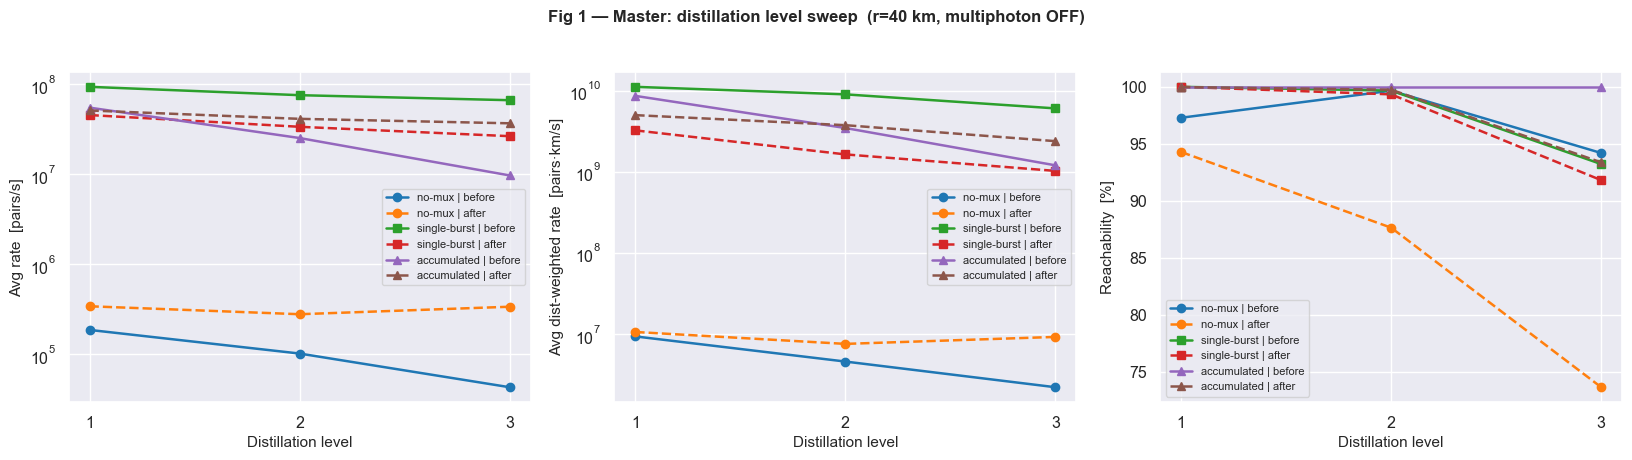

Figure 1 done.


In [4]:
RADIUS_MASTER = 100
LEVELS        = [1, 2, 3]

pal1        = sns.color_palette('tab10', 6)
mux_lbl     = {None: 'no-mux', 'single_burst': 'single-burst', 'accumulated': 'accumulated'}
mux_marker  = {None: 'o', 'single_burst': 's', 'accumulated': '^'}
time_ls     = {'before_swap': '-', 'after_swap': '--'}

fig1, axes1 = make_fig('Fig 1 — Master: distillation level sweep  (r=40 km, multiphoton OFF)')

ci = 0
for mux in MUX_MODES:
    for dtime in DIST_TIMES:
        data = {m: [] for m in METRIC_KEYS}
        for lv in LEVELS:
            print(f'  {mux_lbl[mux]} | {dtime} | level={lv} …')
            res = run_metrics(
                RADIUS_MASTER, distillation=True,
                multiplexing_type=mux, distillation_level=lv,
                distillation_time=dtime,
            )
            for m in METRIC_KEYS:
                data[m].append(res[m])
        plot_line(axes1, LEVELS, data,
                  label=f"{mux_lbl[mux]} | {dtime.replace('_swap', '')}",
                  color=pal1[ci], ls=time_ls[dtime], marker=mux_marker[mux])
        ci += 1

finish_axes(axes1, xlabel='Distillation level', xscale='linear')
for ax in axes1: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('fig1_master.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 done.')

---
## Figure 2 — Distillation level study
Distillation ON, mux=None, before swap. Lines = radii. X-axis = distillation level.

  r=5 km | level=1 …
  r=5 km | level=2 …
  r=5 km | level=3 …
  r=20 km | level=1 …
  r=20 km | level=2 …
  r=20 km | level=3 …
  r=80 km | level=1 …
  r=80 km | level=2 …
  r=80 km | level=3 …
  r=160 km | level=1 …
  r=160 km | level=2 …
  r=160 km | level=3 …


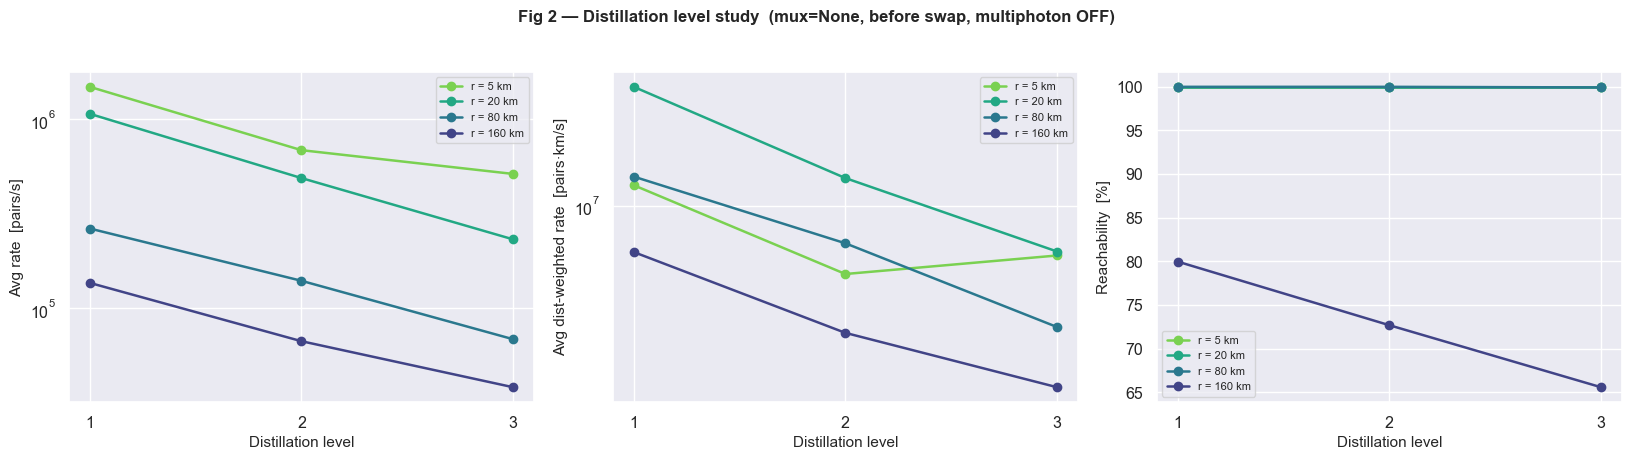

Figure 2 done.


In [5]:
RADII_2  = [5, 20, 80, 160]
pal2     = sns.color_palette('viridis_r', len(RADII_2))

fig2, axes2 = make_fig('Fig 2 — Distillation level study  (mux=None, before swap, multiphoton OFF)')

for ci, r in enumerate(RADII_2):
    data = {m: [] for m in METRIC_KEYS}
    for lv in LEVELS:
        print(f'  r={r} km | level={lv} …')
        res = run_metrics(r, distillation=True, multiplexing_type=None,
                          distillation_level=lv, distillation_time='before_swap')
        for m in METRIC_KEYS: data[m].append(res[m])
    plot_line(axes2, LEVELS, data, label=f'r = {r} km', color=pal2[ci])

finish_axes(axes2, xlabel='Distillation level', xscale='linear')
for ax in axes2: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('fig2_distillation_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 done.')

---
## Figure 3 — Before vs After swap
Distillation ON, mux=None, level=1. X-axis = radius.

  [before swap]  r=10 km …
  [before swap]  r=50 km …
  [before swap]  r=100 km …
  [before swap]  r=175 km …
  [before swap]  r=250 km …
  [before swap]  r=325 km …
  [before swap]  r=400 km …
  [after swap]  r=10 km …
  [after swap]  r=50 km …
  [after swap]  r=100 km …
  [after swap]  r=175 km …
  [after swap]  r=250 km …
  [after swap]  r=325 km …
  [after swap]  r=400 km …


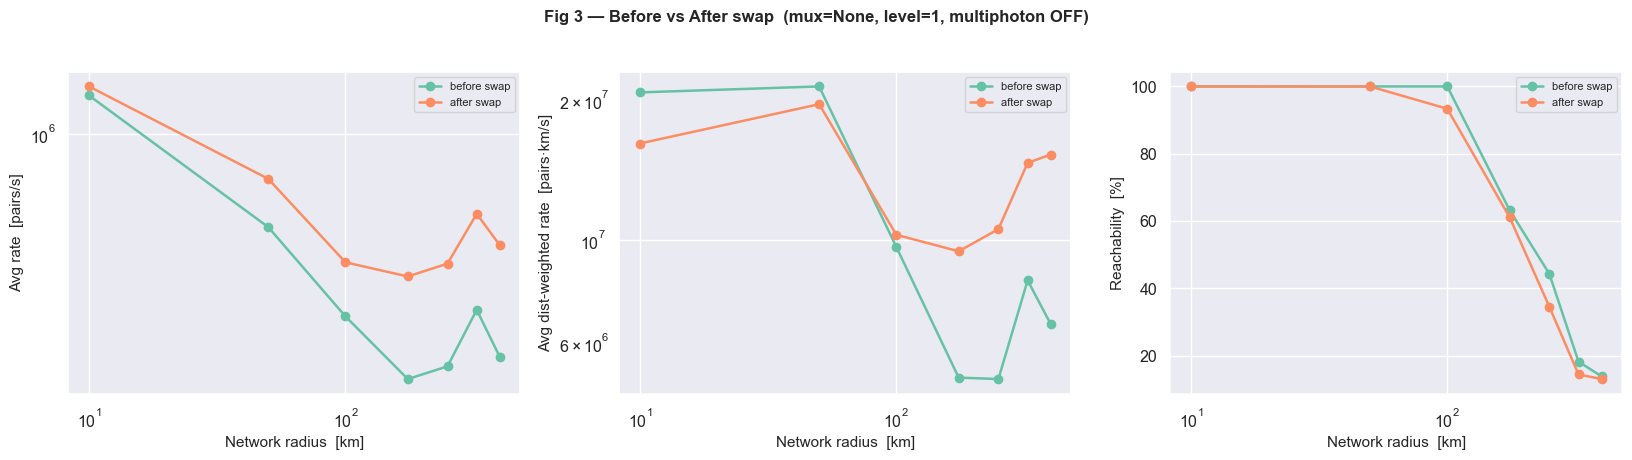

Figure 3 done.


In [6]:
pal3 = sns.color_palette('Set2', 2)
fig3, axes3 = make_fig('Fig 3 — Before vs After swap  (mux=None, level=1, multiphoton OFF)')

for ci, dtime in enumerate(DIST_TIMES):
    data = radius_sweep(RADII, distillation=True, multiplexing_type=None,
                        distillation_level=1, distillation_time=dtime,
                        tag=dtime.replace('_', ' '))
    plot_line(axes3, RADII, data, label=dtime.replace('_', ' '), color=pal3[ci])

finish_axes(axes3, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('fig3_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 done.')

---
## Figure 4 — Distillation vs Accumulated multiplexing
Baseline + distillation levels 1-3 (solid) + accumulated mux no-distillation (dashed). X-axis = radius.

  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist lv1]  r=10 km …
  [dist lv1]  r=50 km …
  [dist lv1]  r=100 km …
  [dist lv1]  r=175 km …
  [dist lv1]  r=250 km …
  [dist lv1]  r=325 km …
  [dist lv1]  r=400 km …
  [dist lv2]  r=10 km …
  [dist lv2]  r=50 km …
  [dist lv2]  r=100 km …
  [dist lv2]  r=175 km …
  [dist lv2]  r=250 km …
  [dist lv2]  r=325 km …
  [dist lv2]  r=400 km …
  [dist lv3]  r=10 km …
  [dist lv3]  r=50 km …
  [dist lv3]  r=100 km …
  [dist lv3]  r=175 km …
  [dist lv3]  r=250 km …
  [dist lv3]  r=325 km …
  [dist lv3]  r=400 km …
  [accumulated mux]  r=10 km …
  [accumulated mux]  r=50 km …
  [accumulated mux]  r=100 km …
  [accumulated mux]  r=175 km …
  [accumulated mux]  r=250 km …
  [accumulated mux]  r=325 km …
  [accumulated mux]  r=400 km …


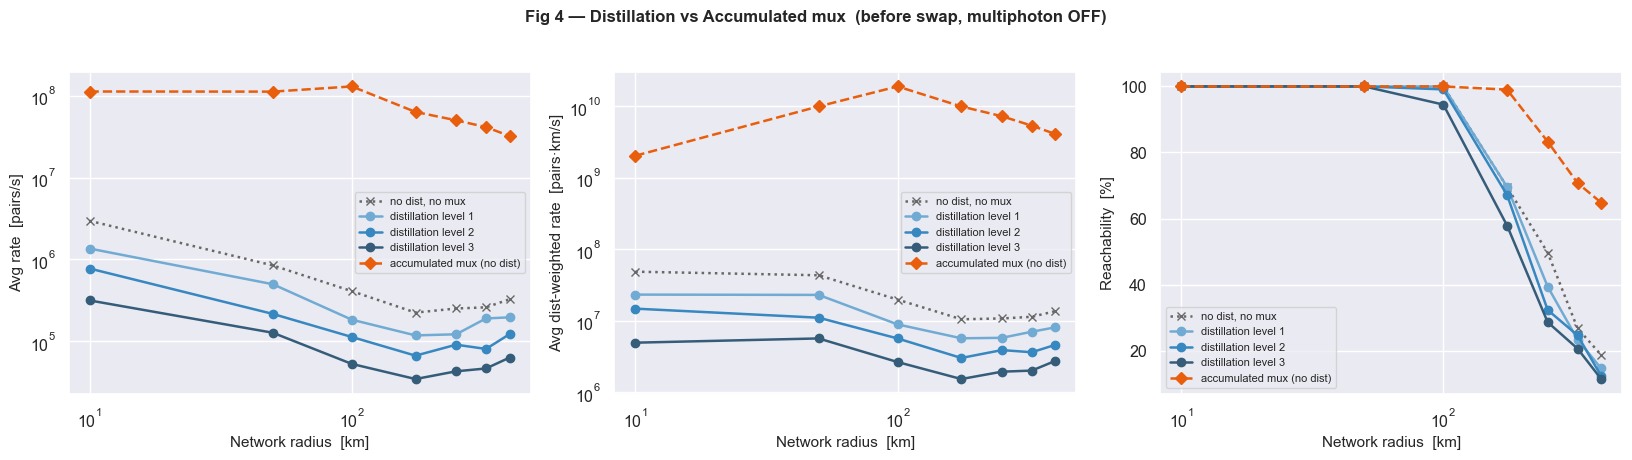

Figure 4 done.


In [7]:
pal4_grey = sns.color_palette('Greys_d', 1)
pal4_blue = sns.color_palette('Blues_d', 3)
pal4_org  = sns.color_palette('Oranges_d', 1)

fig4, axes4 = make_fig('Fig 4 — Distillation vs Accumulated mux  (before swap, multiphoton OFF)')

plot_line(axes4, RADII,
          radius_sweep(RADII, distillation=False, tag='baseline'),
          'no dist, no mux', pal4_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes4, RADII,
              radius_sweep(RADII, distillation=True, multiplexing_type=None,
                           distillation_level=lv, distillation_time='before_swap',
                           tag=f'dist lv{lv}'),
              f'distillation level {lv}', pal4_blue[li])

plot_line(axes4, RADII,
          radius_sweep(RADII, distillation=False, multiplexing_type='accumulated',
                       tag='accumulated mux'),
          'accumulated mux (no dist)', pal4_org[0], ls='--', marker='D')

finish_axes(axes4, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('fig4_dist_vs_accumulated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 done.')

---
## Figure 5 — Distillation vs Single-burst multiplexing
Baseline + distillation-only (solid blue) + single-burst+distillation (dashed green). X-axis = radius.

  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist-only lv1]  r=10 km …
  [dist-only lv1]  r=50 km …
  [dist-only lv1]  r=100 km …
  [dist-only lv1]  r=175 km …
  [dist-only lv1]  r=250 km …
  [dist-only lv1]  r=325 km …
  [dist-only lv1]  r=400 km …
  [dist-only lv2]  r=10 km …
  [dist-only lv2]  r=50 km …
  [dist-only lv2]  r=100 km …
  [dist-only lv2]  r=175 km …
  [dist-only lv2]  r=250 km …
  [dist-only lv2]  r=325 km …
  [dist-only lv2]  r=400 km …
  [dist-only lv3]  r=10 km …
  [dist-only lv3]  r=50 km …
  [dist-only lv3]  r=100 km …
  [dist-only lv3]  r=175 km …
  [dist-only lv3]  r=250 km …
  [dist-only lv3]  r=325 km …
  [dist-only lv3]  r=400 km …
  [single-burst lv1]  r=10 km …
  [single-burst lv1]  r=50 km …
  [single-burst lv1]  r=100 km …
  [single-burst lv1]  r=175 km …
  [single-burst lv1]  r=250 km …
  [single-burst lv1]  r=325 km …
  [sing

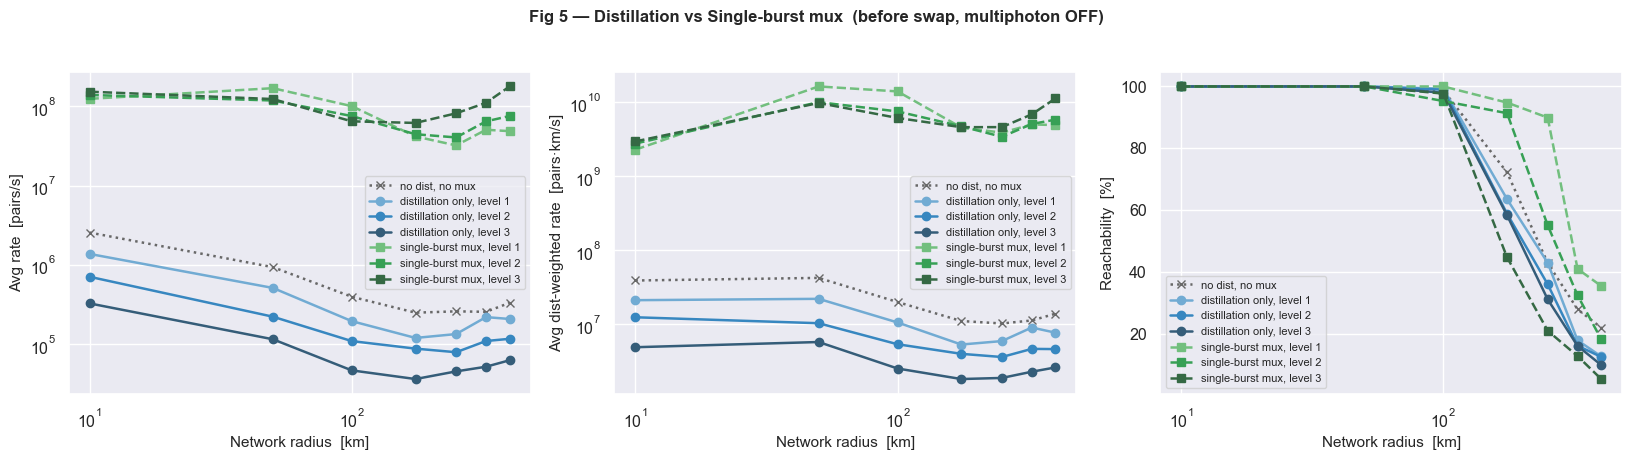

Figure 5 done.


In [8]:
pal5_grey  = sns.color_palette('Greys_d',  1)
pal5_blue  = sns.color_palette('Blues_d',  3)
pal5_green = sns.color_palette('Greens_d', 3)

fig5, axes5 = make_fig('Fig 5 — Distillation vs Single-burst mux  (before swap, multiphoton OFF)')

plot_line(axes5, RADII,
          radius_sweep(RADII, distillation=False, tag='baseline'),
          'no dist, no mux', pal5_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes5, RADII,
              radius_sweep(RADII, distillation=True, multiplexing_type=None,
                           distillation_level=lv, distillation_time='before_swap',
                           tag=f'dist-only lv{lv}'),
              f'distillation only, level {lv}', pal5_blue[li], ls='-', marker='o')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes5, RADII,
              radius_sweep(RADII, distillation=True, multiplexing_type='single_burst',
                           distillation_level=lv, distillation_time='before_swap',
                           tag=f'single-burst lv{lv}'),
              f'single-burst mux, level {lv}', pal5_green[li], ls='--', marker='s')

finish_axes(axes5, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('fig5_dist_vs_singleburst.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 done.')

---
## Figure 6 — P_BSM sweep
Fixed radius = 120 km. All configurations: baseline, distillation levels 1-3,  
accumulated (no dist), accumulated + distillation levels 1-3, single-burst levels 1-3.

  [baseline]  P_BSM=0.05 …
  [baseline]  P_BSM=0.13 …
  [baseline]  P_BSM=0.21 …
  [baseline]  P_BSM=0.30 …
  [baseline]  P_BSM=0.38 …
  [baseline]  P_BSM=0.46 …
  [baseline]  P_BSM=0.54 …
  [baseline]  P_BSM=0.62 …
  [baseline]  P_BSM=0.70 …
  [baseline]  P_BSM=0.79 …
  [baseline]  P_BSM=0.87 …
  [baseline]  P_BSM=0.95 …
  [dist lv1]  P_BSM=0.05 …
  [dist lv1]  P_BSM=0.13 …
  [dist lv1]  P_BSM=0.21 …
  [dist lv1]  P_BSM=0.30 …
  [dist lv1]  P_BSM=0.38 …
  [dist lv1]  P_BSM=0.46 …
  [dist lv1]  P_BSM=0.54 …
  [dist lv1]  P_BSM=0.62 …
  [dist lv1]  P_BSM=0.70 …
  [dist lv1]  P_BSM=0.79 …
  [dist lv1]  P_BSM=0.87 …
  [dist lv1]  P_BSM=0.95 …
  [dist lv2]  P_BSM=0.05 …
  [dist lv2]  P_BSM=0.13 …
  [dist lv2]  P_BSM=0.21 …
  [dist lv2]  P_BSM=0.30 …
  [dist lv2]  P_BSM=0.38 …
  [dist lv2]  P_BSM=0.46 …
  [dist lv2]  P_BSM=0.54 …
  [dist lv2]  P_BSM=0.62 …
  [dist lv2]  P_BSM=0.70 …
  [dist lv2]  P_BSM=0.79 …
  [dist lv2]  P_BSM=0.87 …
  [dist lv2]  P_BSM=0.95 …
  [dist lv3]  P_BSM=0.05 …
 

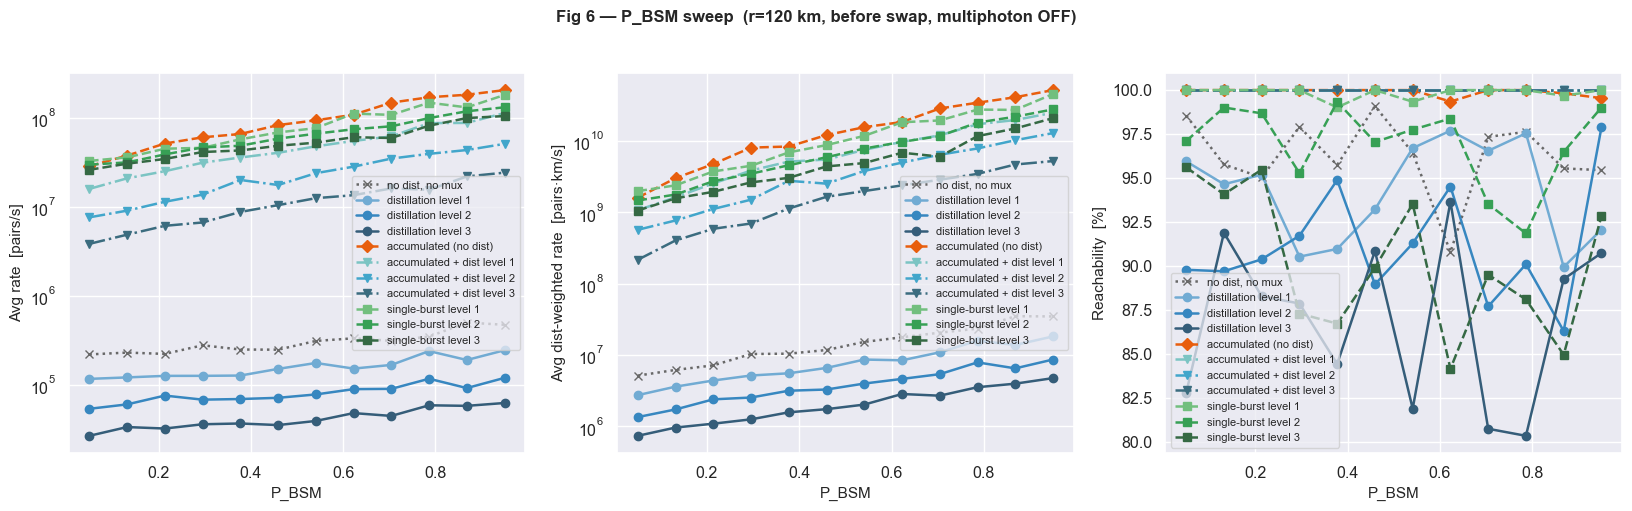

Figure 6 done.


In [9]:
pal6_grey  = sns.color_palette('Greys_d',   1)
pal6_blue  = sns.color_palette('Blues_d',   3)
pal6_org   = sns.color_palette('Oranges_d', 1)
pal6_teal  = sns.color_palette('GnBu_d',    3)
pal6_green = sns.color_palette('Greens_d',  3)

fig6, axes6 = make_fig(f'Fig 6 — P_BSM sweep  (r={RADIUS_LARGE} km, before swap, multiphoton OFF)',
                       height=5)

plot_line(axes6, P_BSM_VALUES,
          pbsm_sweep(P_BSM_VALUES, RADIUS_LARGE, distillation=False, tag='baseline'),
          'no dist, no mux', pal6_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep(P_BSM_VALUES, RADIUS_LARGE, distillation=True,
                         multiplexing_type=None, distillation_level=lv, tag=f'dist lv{lv}'),
              f'distillation level {lv}', pal6_blue[li])

plot_line(axes6, P_BSM_VALUES,
          pbsm_sweep(P_BSM_VALUES, RADIUS_LARGE, distillation=False,
                     multiplexing_type='accumulated', tag='acc no-dist'),
          'accumulated (no dist)', pal6_org[0], ls='--', marker='D')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep(P_BSM_VALUES, RADIUS_LARGE, distillation=True,
                         multiplexing_type='accumulated', distillation_level=lv,
                         tag=f'acc+dist lv{lv}'),
              f'accumulated + dist level {lv}', pal6_teal[li], ls='-.', marker='v')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep(P_BSM_VALUES, RADIUS_LARGE, distillation=True,
                         multiplexing_type='single_burst', distillation_level=lv,
                         tag=f'burst lv{lv}'),
              f'single-burst level {lv}', pal6_green[li], ls='--', marker='s')

finish_axes(axes6, xlabel='P_BSM', xscale='linear')
plt.tight_layout()
plt.savefig('fig6_pbsm_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 done.')

---
## Figure 7 — Multiphoton error ON vs OFF
No distillation, no mux. X-axis = radius.

  [multiphoton OFF]  r=10 km …
  [multiphoton OFF]  r=50 km …
  [multiphoton OFF]  r=100 km …
  [multiphoton OFF]  r=175 km …
  [multiphoton OFF]  r=250 km …
  [multiphoton OFF]  r=325 km …
  [multiphoton OFF]  r=400 km …
  [multiphoton ON]  r=10 km …
  [multiphoton ON]  r=50 km …
  [multiphoton ON]  r=100 km …
  [multiphoton ON]  r=175 km …
  [multiphoton ON]  r=250 km …
  [multiphoton ON]  r=325 km …
  [multiphoton ON]  r=400 km …


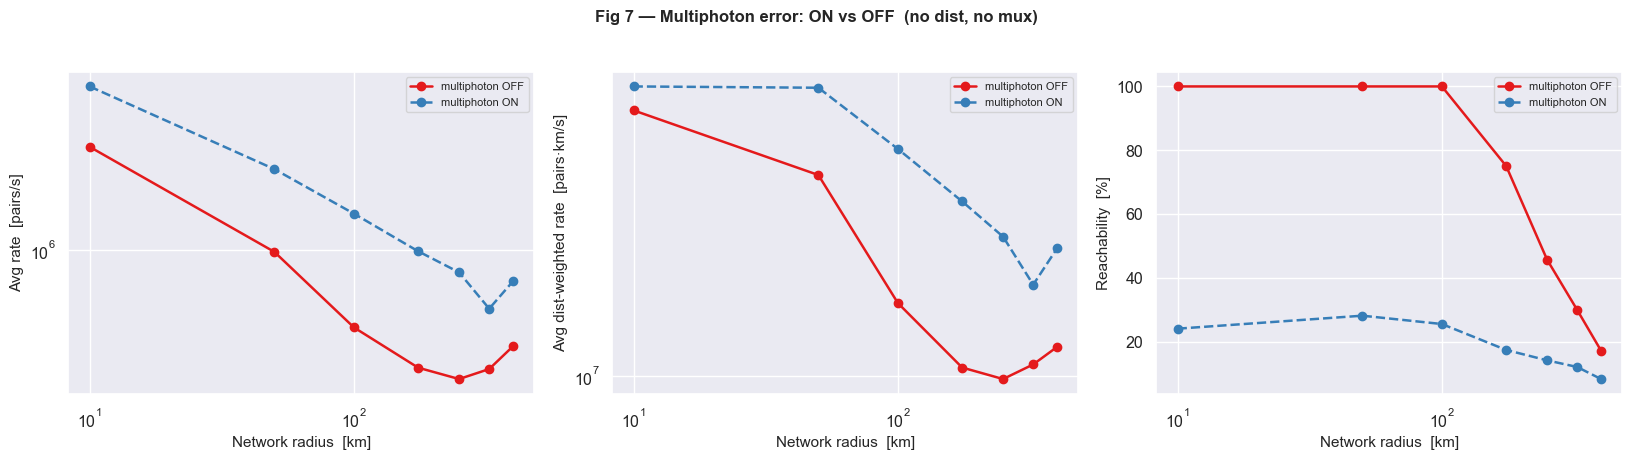

Figure 7 done.


In [10]:
pal7 = sns.color_palette('Set1', 2)
fig7, axes7 = make_fig('Fig 7 — Multiphoton error: ON vs OFF  (no dist, no mux)')

for ci, (mp, lbl) in enumerate([(False, 'multiphoton OFF'), (True, 'multiphoton ON')]):
    data = radius_sweep(RADII, distillation=False, multiphoton=mp, tag=lbl)
    plot_line(axes7, RADII, data, lbl, pal7[ci],
              ls='-' if not mp else '--')

finish_axes(axes7, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('fig7_multiphoton.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 done.')

---
## Figure 8 — Dijkstra path diagnostics: hops & distance vs P_BSM
Fixed (src, tgt) pair. Vary P_BSM. Three panels = three radii.  
Shaded band = min–max across N_TRIALS realisations.

  r=10 km  P_BSM=0.05 …
  r=10 km  P_BSM=0.13 …
  r=10 km  P_BSM=0.21 …
  r=10 km  P_BSM=0.30 …
  r=10 km  P_BSM=0.38 …
  r=10 km  P_BSM=0.46 …
  r=10 km  P_BSM=0.54 …
  r=10 km  P_BSM=0.62 …
  r=10 km  P_BSM=0.70 …
  r=10 km  P_BSM=0.79 …
  r=10 km  P_BSM=0.87 …
  r=10 km  P_BSM=0.95 …
  r=40 km  P_BSM=0.05 …
  r=40 km  P_BSM=0.13 …
  r=40 km  P_BSM=0.21 …
  r=40 km  P_BSM=0.30 …
  r=40 km  P_BSM=0.38 …
  r=40 km  P_BSM=0.46 …
  r=40 km  P_BSM=0.54 …
  r=40 km  P_BSM=0.62 …
  r=40 km  P_BSM=0.70 …
  r=40 km  P_BSM=0.79 …
  r=40 km  P_BSM=0.87 …
  r=40 km  P_BSM=0.95 …
  r=160 km  P_BSM=0.05 …
  r=160 km  P_BSM=0.13 …
  r=160 km  P_BSM=0.21 …
  r=160 km  P_BSM=0.30 …
  r=160 km  P_BSM=0.38 …
  r=160 km  P_BSM=0.46 …
  r=160 km  P_BSM=0.54 …
  r=160 km  P_BSM=0.62 …
  r=160 km  P_BSM=0.70 …
  r=160 km  P_BSM=0.79 …
  r=160 km  P_BSM=0.87 …
  r=160 km  P_BSM=0.95 …


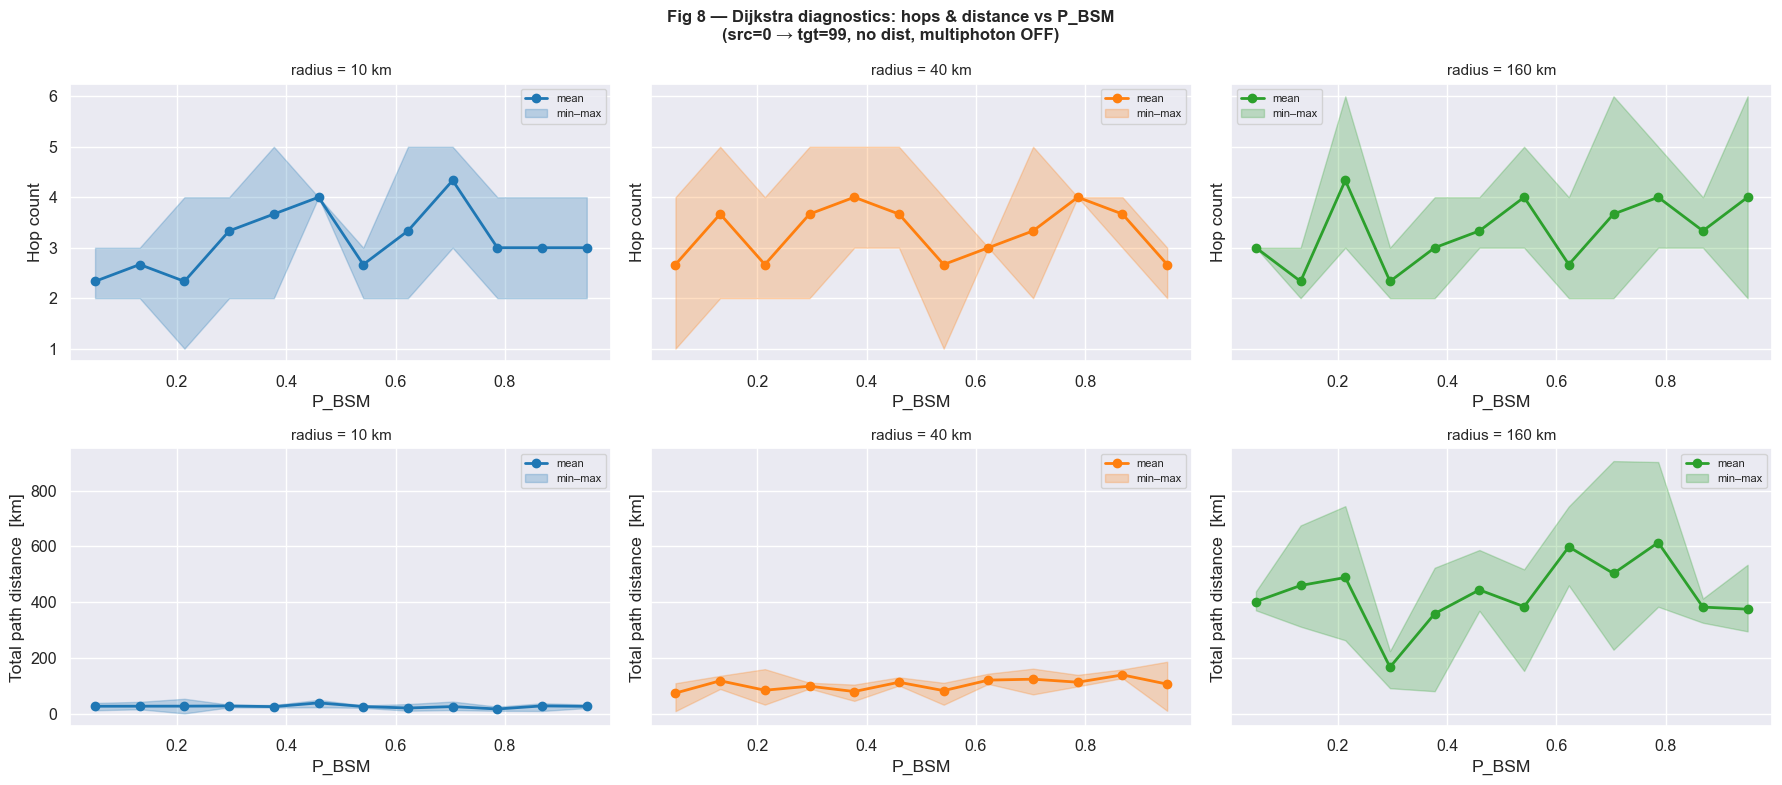

Figure 8 done.


In [11]:
def dijkstra_diag(radius_km, P_BSM_vals, src=SOURCE_NODE, tgt=TARGET_NODE,
                  n_trials=N_TRIALS):
    """Return (hops_mean, hops_min, hops_max, dist_mean, dist_min, dist_max)."""
    hm, hmin, hmax, dm, dmin, dmax = [], [], [], [], [], []
    for pb in P_BSM_vals:
        print(f'  r={radius_km} km  P_BSM={pb:.2f} …')
        h_all, d_all = [], []
        for _ in range(n_trials):
            A, dist_mtx, coords, _ = build_radius_graph(N_NODES, radius_km, BETA, MU)
            net = QuantumRepeaterNetwork(
                make_params(pb), A, dist_mtx, coords,
                architecture='node', scale=float(radius_km),
                multiphoton=False, distillation=False,
            )
            try:
                _, path = net.optimal_path(src, target=tgt)
                h_all.append(len(path) - 1)
                d_all.append(sum(net.path_distances(path)))
            except Exception:
                h_all.append(np.nan)
                d_all.append(np.nan)
        h, d = np.array(h_all, float), np.array(d_all, float)
        hm.append(np.nanmean(h));  hmin.append(np.nanmin(h));  hmax.append(np.nanmax(h))
        dm.append(np.nanmean(d));  dmin.append(np.nanmin(d));  dmax.append(np.nanmax(d))
    return (np.array(hm), np.array(hmin), np.array(hmax),
            np.array(dm), np.array(dmin), np.array(dmax))


n_panels = len(RADII_DIJKSTRA)
fig8, axes8 = plt.subplots(2, n_panels, figsize=(6 * n_panels, 8), sharey='row')
fig8.suptitle(
    f'Fig 8 — Dijkstra diagnostics: hops & distance vs P_BSM\n'
    f'(src={SOURCE_NODE} → tgt={TARGET_NODE}, no dist, multiphoton OFF)',
    fontsize=12, fontweight='bold'
)

pal8 = sns.color_palette('tab10', n_panels)

for ci, r in enumerate(RADII_DIJKSTRA):
    hm, hmin, hmax, dm, dmin, dmax = dijkstra_diag(r, P_BSM_VALUES)
    c = pal8[ci]

    for row_ax, (mean_v, lo, hi, ylabel) in zip(
        axes8[:, ci],
        [(hm, hmin, hmax, 'Hop count'),
         (dm, dmin, dmax, 'Total path distance  [km]')]
    ):
        row_ax.plot(P_BSM_VALUES, mean_v, color=c, lw=2, marker='o', label='mean')
        row_ax.fill_between(P_BSM_VALUES, lo, hi, color=c, alpha=0.25, label='min–max')
        row_ax.set_title(f'radius = {r} km', fontsize=11)
        row_ax.set_xlabel('P_BSM')
        row_ax.set_ylabel(ylabel)
        row_ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8_dijkstra_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 done.')

---
## Figure 9 — Bonus density plots
### 9a — SKR heatmap (all pairs, one graph)
### 9b/c — KDE of hop count & path distance, lines per radius
### 9d — Joint 2-D density: hops vs log₁₀(SKR), panels per radius

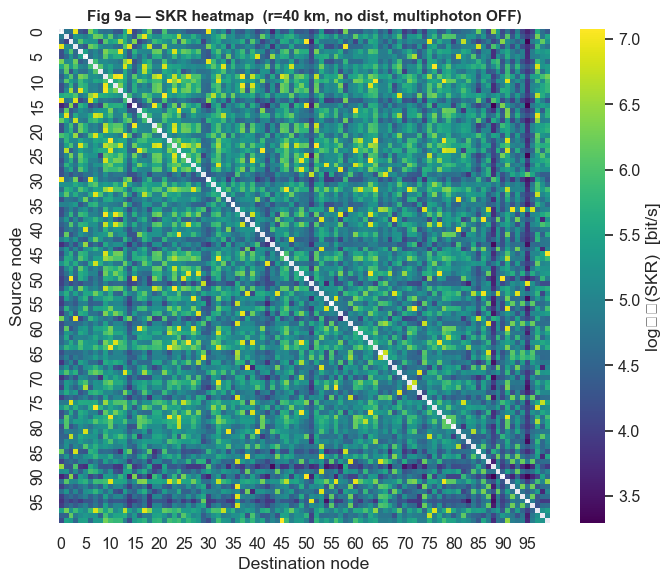

Figure 9a done.


In [12]:
# ── 9a: SKR heatmap ──────────────────────────────────────────────────────────
RADIUS_HMAP = 40
A_h, dist_h, coords_h, _ = build_radius_graph(N_NODES, RADIUS_HMAP, BETA, MU)
net_h = QuantumRepeaterNetwork(
    make_params(), A_h, dist_h, coords_h,
    architecture='node', scale=float(RADIUS_HMAP),
    multiphoton=False, distillation=False,
)

SKR_mat = np.full((N_NODES, N_NODES), np.nan)
for src in range(N_NODES):
    df = net_h.analyze_all_paths(src)
    for dst, row in df.iterrows():
        skr = row['SKR']
        SKR_mat[src, dst] = np.log10(skr) if skr > 0 else np.nan

fig9a, ax9a = plt.subplots(figsize=(7, 6))
sns.heatmap(SKR_mat, ax=ax9a, cmap='viridis',
            cbar_kws={'label': 'log₁₀(SKR)  [bit/s]'},
            xticklabels=5, yticklabels=5)
ax9a.set_title(f'Fig 9a — SKR heatmap  (r={RADIUS_HMAP} km, no dist, multiphoton OFF)',
               fontsize=11, fontweight='bold')
ax9a.set_xlabel('Destination node')
ax9a.set_ylabel('Source node')
plt.tight_layout()
plt.savefig('fig9a_skr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9a done.')

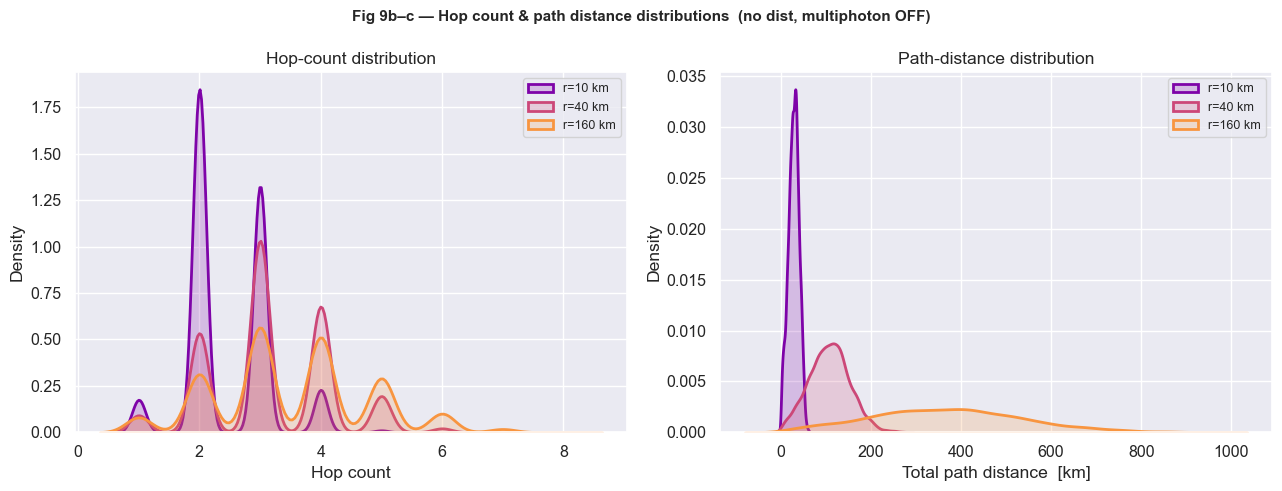

Figure 9b–c done.


In [13]:
# ── 9b/c: KDE of hop count and path distance ─────────────────────────────────
pal9 = sns.color_palette('plasma', len(RADII_KDE))
fig9bc, axes9bc = plt.subplots(1, 2, figsize=(13, 5))
fig9bc.suptitle('Fig 9b–c — Hop count & path distance distributions  (no dist, multiphoton OFF)',
                fontsize=11, fontweight='bold')

for ci, r in enumerate(RADII_KDE):
    A_k, dist_k, coords_k, _ = build_radius_graph(N_NODES, r, BETA, MU)
    net_k = QuantumRepeaterNetwork(
        make_params(), A_k, dist_k, coords_k,
        architecture='node', scale=float(r),
        multiphoton=False, distillation=False,
    )
    hops_all, dists_all = [], []
    for src in range(N_NODES):
        df = net_k.analyze_all_paths(src)
        for dst, row in df.iterrows():
            if row['SKR'] > 0:
                hops_all.append(len(row['path']) - 1)
                dists_all.append(sum(net_k.path_distances(row['path'])))
    if len(hops_all) > 1:
        sns.kdeplot(hops_all,  ax=axes9bc[0], color=pal9[ci],
                    label=f'r={r} km', lw=2, fill=True, alpha=0.2)
        sns.kdeplot(dists_all, ax=axes9bc[1], color=pal9[ci],
                    label=f'r={r} km', lw=2, fill=True, alpha=0.2)

for ax, xlabel, title in zip(
    axes9bc,
    ['Hop count', 'Total path distance  [km]'],
    ['Hop-count distribution', 'Path-distance distribution']
):
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(title);   ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig9bc_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9b–c done.')

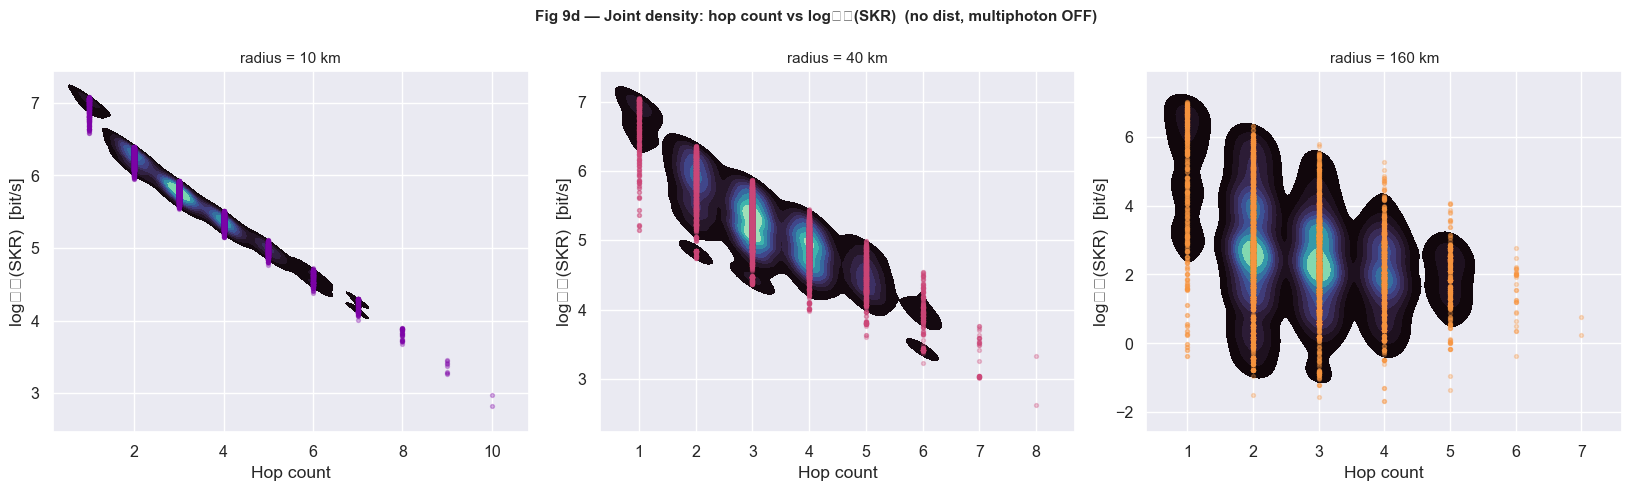

Figure 9d done.


In [14]:
# ── 9d: 2-D joint density: hops vs log₁₀(SKR) ───────────────────────────────
fig9d, axes9d = plt.subplots(1, len(RADII_KDE),
                              figsize=(5.5 * len(RADII_KDE), 5))
fig9d.suptitle('Fig 9d — Joint density: hop count vs log₁₀(SKR)  (no dist, multiphoton OFF)',
               fontsize=11, fontweight='bold')

for ci, r in enumerate(RADII_KDE):
    A_k, dist_k, coords_k, _ = build_radius_graph(N_NODES, r, BETA, MU)
    net_k = QuantumRepeaterNetwork(
        make_params(), A_k, dist_k, coords_k,
        architecture='node', scale=float(r),
        multiphoton=False, distillation=False,
    )
    hops_j, skr_j = [], []
    for src in range(N_NODES):
        df = net_k.analyze_all_paths(src)
        for dst, row in df.iterrows():
            if row['SKR'] > 0:
                hops_j.append(len(row['path']) - 1)
                skr_j.append(np.log10(row['SKR']))

    ax = axes9d[ci]
    if len(hops_j) > 5:
        df_j = pd.DataFrame({'Hops': hops_j, 'log₁₀(SKR)': skr_j})
        sns.kdeplot(data=df_j, x='Hops', y='log₁₀(SKR)',
                    ax=ax, fill=True, cmap='mako', thresh=0.05, levels=10)
        ax.scatter(hops_j, skr_j, s=8, alpha=0.3, color=pal9[ci], zorder=3)
    ax.set_title(f'radius = {r} km', fontsize=11)
    ax.set_xlabel('Hop count')
    ax.set_ylabel('log₁₀(SKR)  [bit/s]')

plt.tight_layout()
plt.savefig('fig9d_joint_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9d done.')